# 🧠 Modelo LSTM — Pronóstico de Rentas Cedidas

**Componente de Tesis: Red Neuronal Recurrente (Deep Learning)**

LSTM (Long Short-Term Memory) captura dependencias temporales a largo plazo
que modelos lineales no pueden detectar.

**Metodología:**
1. Preparación de base optimizada para redes neuronales
2. Normalización MinMaxScaler (rango 0-1)
3. Secuencias temporales de 12 pasos
4. Arquitectura LSTM(64) → Dropout(0.2) → Dense(1)
5. Early stopping para evitar sobreajuste

---

In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../scripts')
%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from utils import cargar_datos, agregar_mensual, calcular_metricas, formato_pesos

# Intentar PyTorch primero (compatible con Python 3.12)
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    BACKEND = 'pytorch'
    print(f'✅ PyTorch {torch.__version__} — GPU: {torch.cuda.is_available()}')
except ImportError:
    try:
        from tensorflow import keras
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import LSTM as LSTM_Layer, Dense, Dropout
        from tensorflow.keras.callbacks import EarlyStopping
        BACKEND = 'tensorflow'
        print('✅ TensorFlow/Keras importado')
    except ImportError:
        BACKEND = None
        print('❌ Ni PyTorch ni TensorFlow disponibles. Instalar: pip install torch')

print(f'Backend seleccionado: {BACKEND}')


  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


✅ PyTorch 2.9.0+cpu — GPU: False
Backend seleccionado: pytorch


## 1. Preparación de Base Optimizada para LSTM

### ¿Por qué LSTM necesita una base diferente?

Las redes neuronales LSTM requieren transformaciones específicas que otros modelos no necesitan:

| Característica | Justificación |
|---|---|
| **Normalización [0,1]** | Las redes neuronales convergen mejor con valores en rango estrecho. Sin normalizar, los gradientes explotan o desaparecen |
| **Secuencias de ventana fija** | LSTM procesa secuencias ordenadas de longitud fija (lookback=12 meses) para aprender patrones estacionales |
| **Solo la serie univariada** | A diferencia de XGBoost, LSTM aprende features internamente. Demasiadas variables con pocas observaciones causa sobreajuste |
| **Sin NaN ni huecos** | Las redes neuronales no toleran valores faltantes; se interpolan si es necesario |
| **Formato tensorial 3D** | Entrada: (muestras, pasos_temporales, features) — requerido por la arquitectura LSTM |

### ⚠️ Limitante Crítica: Tamaño Muestral (N=48)
Al restringir el historial al periodo robusto (2022-2025), contamos exactamente con **48 observaciones**. Las redes neuronales profundas como LSTM usualmente requieren cientos o miles de observaciones para converger óptimamente. Con $N=48$, diferenciando estacionalmente ($N=36$) y usando ventanas (*lookback*=6), apenas restan **30 secuencias** para entrenar. Esto explica la rápida propensión al sobreajuste y la varianza en los resultados. Se compensa parcialmente con *Dropout* y *Early Stopping*.


In [2]:
# 1.1 Cargar serie mensual base
try:
    df_mensual = pd.read_csv(DATA_PROCESSED / 'serie_mensual.csv', index_col=0, parse_dates=True)
except FileNotFoundError:
    df = cargar_datos(DATA_FILE)
    df_mensual = agregar_mensual(df)

serie_original = df_mensual['Recaudo_Neto'].copy()
serie = np.log1p(df_mensual['Recaudo_Neto'].copy())
serie = serie.loc['2022-01-01':] # Limitando datos > 2022 explicitamente
print('Aplicando np.log1p() para estabilizar varianza...')
print(f'Serie original: {len(serie)} observaciones')
print(f'Rango: {serie.min():,.0f} — {serie.max():,.0f}')
print(f'NaN: {serie.isna().sum()}')

# 1.2 Verificar continuidad temporal (sin huecos)
freq_esperada = pd.DateOffset(months=1)
gaps = []
for i in range(1, len(serie)):
    diff = (serie.index[i].year - serie.index[i-1].year) * 12 + (serie.index[i].month - serie.index[i-1].month)
    if diff != 1:
        gaps.append((serie.index[i-1], serie.index[i], diff))
if gaps:
    print(f'⚠️ Huecos detectados: {gaps}')
    # Rellenar con interpolación lineal
    serie = serie.asfreq('MS').interpolate(method='linear')
    print(f'   Interpolados. Nueva longitud: {len(serie)}')
else:
    print('✅ Serie continua sin huecos')


Aplicando np.log1p() para estabilizar varianza...
Serie original: 48 observaciones
Rango: 26 — 27
NaN: 0
✅ Serie continua sin huecos


In [3]:
# 1.3 Diferenciación Estacional (YoY) y Normalización
# JUSTIFICACIÓN: Al restar el valor del mismo mes del año anterior (y_t - y_{t-12}),
# eliminamos la estacionalidad pesada y la tendencia, permitiendo que la LSTM
# se enfoque en predecir desviaciones o anomalías anuales.

serie_diff = (serie - serie.shift(12)).dropna()
print(f'✅ Serie diferenciada (YoY): {len(serie_diff)} meses')

scaler = MinMaxScaler(feature_range=(-1, 1)) # Rango centrado para residuos
serie_scaled = scaler.fit_transform(serie_diff.values.reshape(-1, 1)).flatten()

print(f'\n📊 Normalización MinMaxScaler (Residuos YoY):')
print(f'   Media residuos: {serie_diff.mean():,.0f}')
print(f'   Rango escalado: [{serie_scaled.min():.4f}, {serie_scaled.max():.4f}]')


✅ Serie diferenciada (YoY): 36 meses

📊 Normalización MinMaxScaler (Residuos YoY):
   Media residuos: 0
   Rango escalado: [-1.0000, 1.0000]


In [4]:
# 1.4 Crear secuencias temporales
# Con la serie diferenciada, una ventana de 6 meses captura mejor la inercia anual.
LOOKBACK = 6 

def crear_secuencias(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X_seq, y_seq = crear_secuencias(serie_scaled, LOOKBACK)
print(f'\n📊 Secuencias (lookback={LOOKBACK}):')
print(f'   Forma X: {X_seq.shape}')



📊 Secuencias (lookback=6):
   Forma X: (30, 6)


In [5]:
# 1.5 Split Train/Test temporal
# Las fechas de las secuencias corresponden a serie_diff[LOOKBACK:]
fechas_seq = serie_diff.index[LOOKBACK:]
train_idx = fechas_seq <= TRAIN_END
test_idx = fechas_seq >= TEST_START

X_train = X_seq[train_idx]
y_train = y_seq[train_idx]
X_test = X_seq[test_idx]
y_test = y_seq[test_idx]

X_train_3d = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_3d = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f'\n📊 Split Temporal (YoY Diferenciado):')
print(f'   Train: {len(X_train)} samples')
print(f'   Test:  {len(X_test)} samples')



📊 Split Temporal (YoY Diferenciado):
   Train: 27 samples
   Test:  3 samples


## 2. Arquitectura del Modelo LSTM

In [6]:
if BACKEND == 'pytorch':
    class LSTMModel(nn.Module):
        def __init__(self, input_size=1, hidden_size=12, num_layers=1, dropout=0.1):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                              batch_first=True, dropout=dropout if num_layers > 1 else 0)
            self.fc = nn.Linear(hidden_size, 1)
        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :])
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    modelo_lstm = LSTMModel().to(device)
    print(f'Modelo LSTM (PyTorch) en {device}:')
    print(modelo_lstm)
    print(f'Parámetros: {sum(p.numel() for p in modelo_lstm.parameters()):,}')

elif BACKEND == 'tensorflow':
    modelo_lstm = Sequential([
        LSTM_Layer(12, return_sequences=False, input_shape=(LOOKBACK, 1)),
        Dropout(0.1),
        Dense(1)
    ])
    modelo_lstm.compile(optimizer='adam', loss='huber')
    modelo_lstm.summary()
else:
    print('❌ Sin backend disponible. Instalar: pip install torch')


Modelo LSTM (PyTorch) en cpu:
LSTMModel(
  (lstm): LSTM(1, 12, batch_first=True)
  (fc): Linear(in_features=12, out_features=1, bias=True)
)
Parámetros: 733


## 3. Entrenamiento con Early Stopping

In [7]:
EPOCHS = 1000
BATCH_SIZE = 4
PATIENCE = 150

if BACKEND == 'pytorch':
    X_tr = torch.FloatTensor(X_train_3d).to(device)
    y_tr = torch.FloatTensor(y_train).unsqueeze(1).to(device)
    X_te = torch.FloatTensor(X_test_3d).to(device)
    y_te = torch.FloatTensor(y_test).unsqueeze(1).to(device)
    
    optimizer = torch.optim.Adam(modelo_lstm.parameters(), lr=0.001)
    criterion = nn.HuberLoss()
    
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None
    
    for epoch in range(EPOCHS):
        modelo_lstm.train()
        optimizer.zero_grad()
        pred = modelo_lstm(X_tr)
        loss = criterion(pred, y_tr)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        modelo_lstm.eval()
        with torch.no_grad():
            val_pred = modelo_lstm(X_te)
            val_loss = criterion(val_pred, y_te).item()
        val_losses.append(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = modelo_lstm.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= PATIENCE:
            print(f'Early stopping en epoch {epoch+1}')
            break
        if (epoch+1) % 20 == 0:
            print(f'Epoch {epoch+1}/{EPOCHS} — Train Loss: {loss.item():.6f} | Val Loss: {val_loss:.6f}')
    
    modelo_lstm.load_state_dict(best_state)
    history = {'train_loss': train_losses, 'val_loss': val_losses}

elif BACKEND == 'tensorflow':
    es = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)
    history_obj = modelo_lstm.fit(
        X_train_3d, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_data=(X_test_3d, y_test), callbacks=[es], verbose=1
    )
    history = {'train_loss': history_obj.history['loss'], 'val_loss': history_obj.history['val_loss']}


Epoch 20/1000 — Train Loss: 0.131688 | Val Loss: 0.195199
Epoch 40/1000 — Train Loss: 0.131202 | Val Loss: 0.195333


Epoch 60/1000 — Train Loss: 0.130686 | Val Loss: 0.191754
Epoch 80/1000 — Train Loss: 0.129965 | Val Loss: 0.188987


Epoch 100/1000 — Train Loss: 0.128903 | Val Loss: 0.185406
Epoch 120/1000 — Train Loss: 0.127409 | Val Loss: 0.180913


Epoch 140/1000 — Train Loss: 0.125882 | Val Loss: 0.174235
Epoch 160/1000 — Train Loss: 0.125071 | Val Loss: 0.167013


Epoch 180/1000 — Train Loss: 0.124226 | Val Loss: 0.162692
Epoch 200/1000 — Train Loss: 0.123054 | Val Loss: 0.157432


Epoch 220/1000 — Train Loss: 0.121194 | Val Loss: 0.150712
Epoch 240/1000 — Train Loss: 0.117590 | Val Loss: 0.144045


Epoch 260/1000 — Train Loss: 0.108477 | Val Loss: 0.149255
Epoch 280/1000 — Train Loss: 0.092865 | Val Loss: 0.189898


Epoch 300/1000 — Train Loss: 0.070453 | Val Loss: 0.213438
Epoch 320/1000 — Train Loss: 0.045376 | Val Loss: 0.254187


Epoch 340/1000 — Train Loss: 0.027758 | Val Loss: 0.257572
Epoch 360/1000 — Train Loss: 0.016489 | Val Loss: 0.219607
Epoch 380/1000 — Train Loss: 0.008849 | Val Loss: 0.195143


Early stopping en epoch 398


## 4. Curvas de Aprendizaje

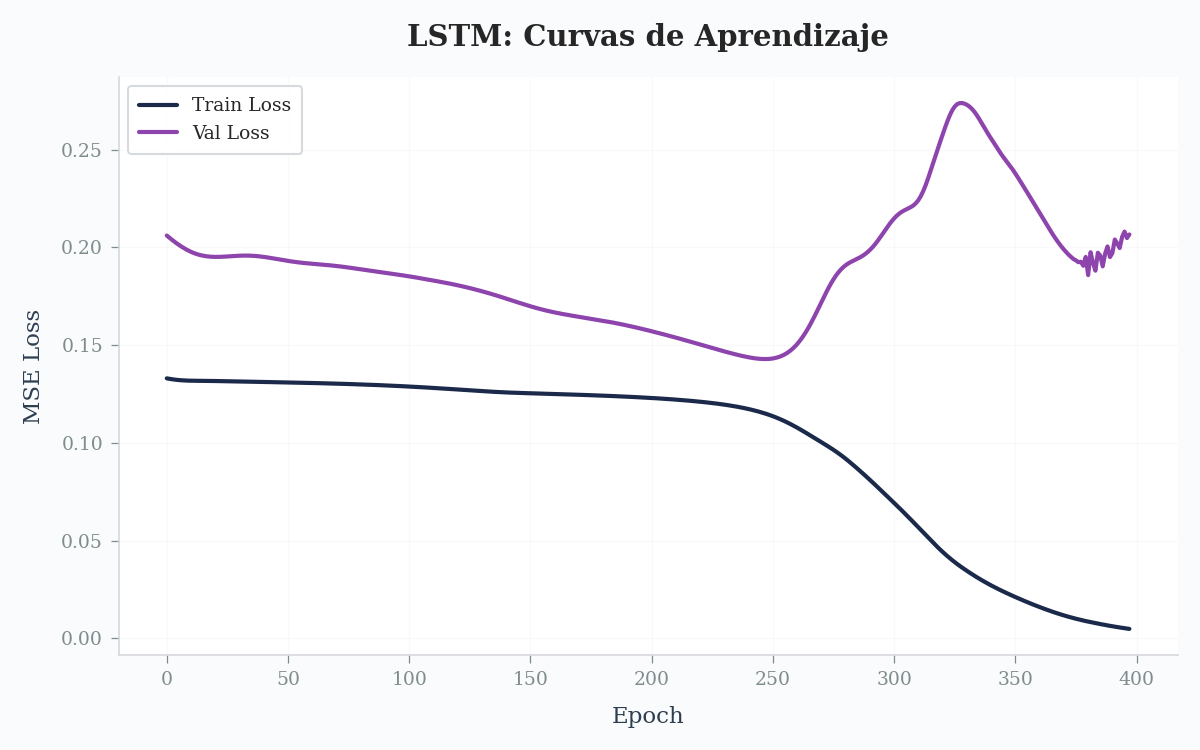

In [8]:
fig, ax = plt.subplots(figsize=FIGSIZE_SMALL)
ax.plot(history['train_loss'], label='Train Loss', color=COLORES['real'])
ax.plot(history['val_loss'], label='Val Loss', color=COLORES['lstm'])
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM: Curvas de Aprendizaje', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '08_lstm_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Predicción y Desescalado

In [9]:
# Predicción escalada (de residuos YoY)
if BACKEND == 'pytorch':
    modelo_lstm.eval()
    with torch.no_grad():
        y_pred_scaled = modelo_lstm(X_te).cpu().numpy().flatten()
elif BACKEND == 'tensorflow':
    y_pred_scaled = modelo_lstm.predict(X_test_3d).flatten()

# 1. Desescalar residuos predichos
y_pred_diff = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_diff = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# 2. RECONSTRUCCIÓN: y_t = y_{t-12} + error_predicho
fechas_test = fechas_seq[test_idx]
y_prev_year = serie.loc[fechas_test - pd.DateOffset(years=1)].values

y_pred_lstm_log = y_prev_year + y_pred_diff
y_test_original_log = y_prev_year + y_test_diff

y_pred_lstm = np.expm1(y_pred_lstm_log)
y_test_original = np.expm1(y_test_original_log)

# Métricas finales sobre escala original
metricas_lstm = calcular_metricas(y_test_original, y_pred_lstm, 'LSTM (YoY Diff)')



📈 Métricas — LSTM (YoY Diff)
   RMSE:  41,044,925,851
   MAE:   31,491,683,661
   MAPE:  10.82%
   R²:    -0.7965


## 6. Gráfico de Pronóstico

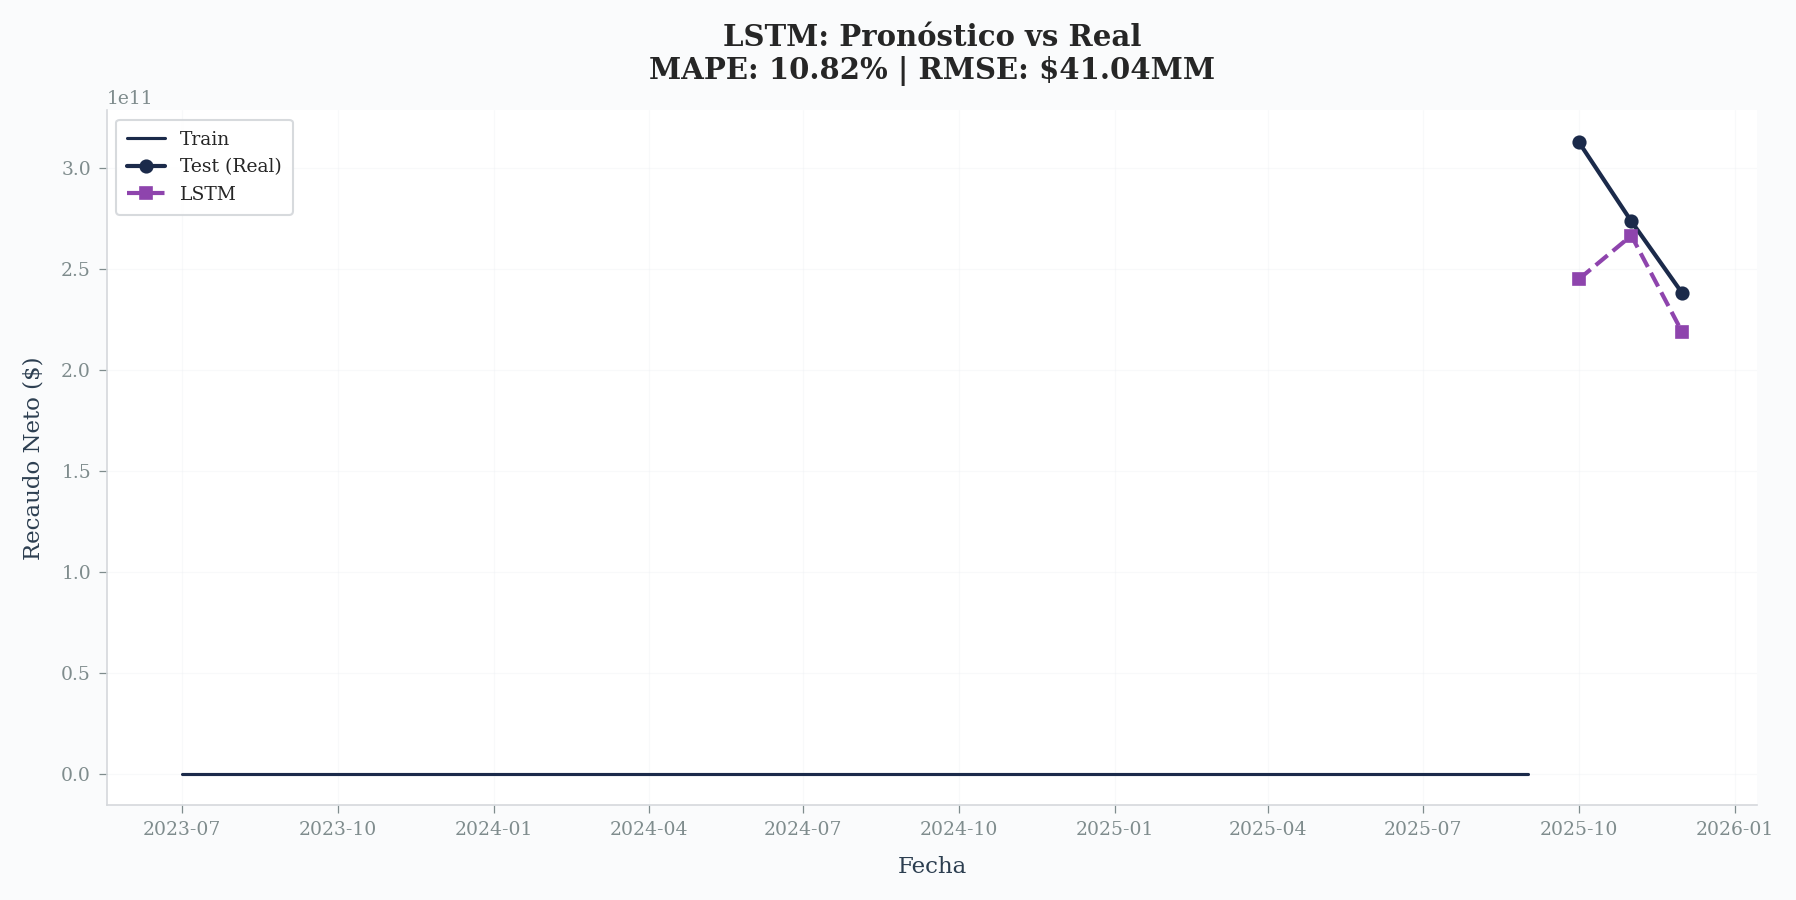

In [10]:
fechas_test = fechas_seq[test_idx]
fechas_train = fechas_seq[train_idx]
y_train_orig = serie.loc[fechas_seq[train_idx]].values

fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD)
ax.plot(fechas_train, y_train_orig, color=COLORES['real'], linewidth=1.5, label='Train')
ax.plot(fechas_test, y_test_original, 'o-', color=COLORES['real'], linewidth=2, markersize=6, label='Test (Real)')
ax.plot(fechas_test, y_pred_lstm, 's--', color=COLORES['lstm'], linewidth=2, markersize=6, label='LSTM')
ax.set_title(f'LSTM: Pronóstico vs Real\nMAPE: {metricas_lstm["MAPE (%)"]:.2f}% | RMSE: {formato_pesos(metricas_lstm["RMSE"])}', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Recaudo Neto ($)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '08_lstm_pronostico.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.1 Test de Ruido Blanco (Ljung-Box)

Test Ljung-Box sobre Residuos (H0: Ruido Blanco independent)


,lb_stat,lb_pvalue
1,0.615147,0.432856


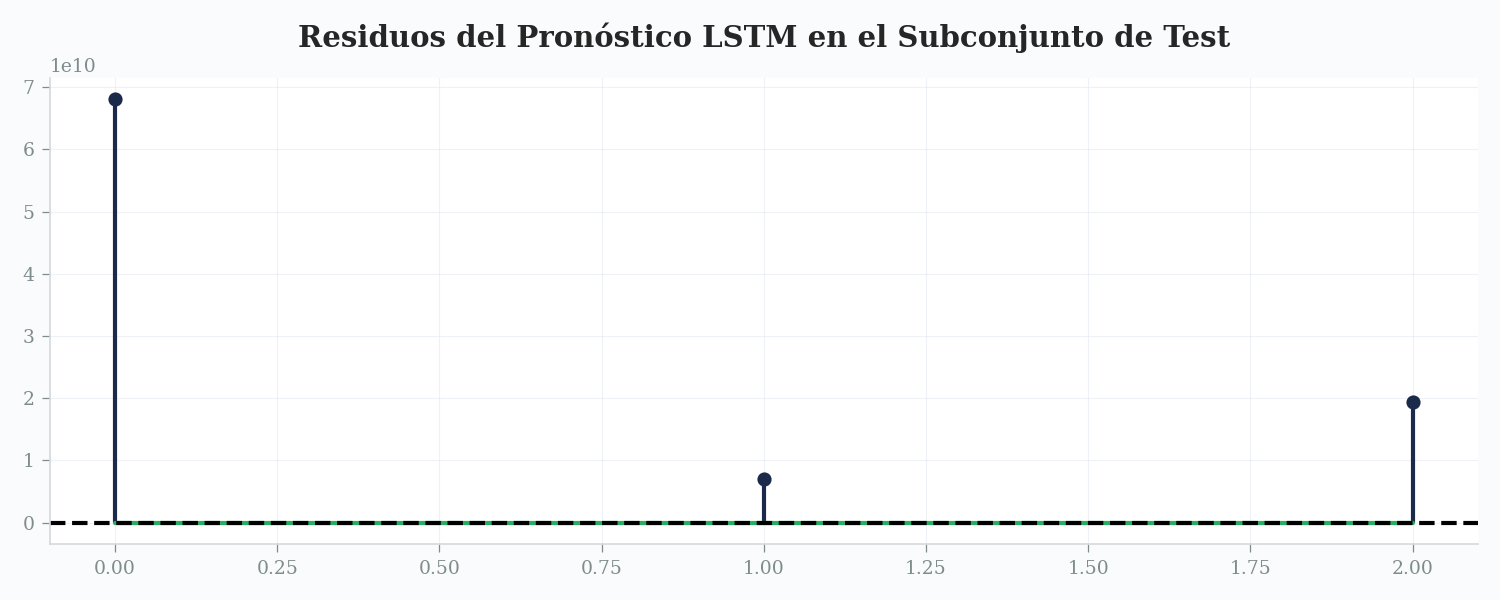

In [11]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

# Test de ruido blanco sobre residuos de prueba
residuos_test = y_test_original - y_pred_lstm

lb_test = acorr_ljungbox(residuos_test, lags=[min(6, len(residuos_test)//2)], return_df=True)
print("Test Ljung-Box sobre Residuos (H0: Ruido Blanco independent)")
display(lb_test)

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(range(len(residuos_test)), residuos_test)
ax.set_title('Residuos del Pronóstico LSTM en el Subconjunto de Test')
ax.axhline(0, color='black', linestyle='--')
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '08_lstm_residuos.png', dpi=150)
plt.show()

## 7. Exportar Resultados

In [12]:
pd.DataFrame({'Fecha': fechas_test, 'Real': y_test_original, 'Pronostico_LSTM': y_pred_lstm}).to_csv(OUTPUTS_FORECASTS / 'lstm_forecast.csv', index=False)
pd.DataFrame([metricas_lstm]).to_csv(OUTPUTS_REPORTS / 'lstm_metricas.csv', index=False)

print('\n' + '='*60)
print('  ✅ LSTM COMPLETADO — Proceder con 09_Comparacion_Modelos.ipynb')
print('='*60)



  ✅ LSTM COMPLETADO — Proceder con 09_Comparacion_Modelos.ipynb
